# Degradation & Encoder Visualization Notebook

This notebook visualizes:
1. **4 Degradation Types**: What degradations are applied to raw images
2. **Encoder Inputs**: What the encoder actually sees (concatenated inputs)
3. **Encoder Outputs**: Feature maps at different hierarchical levels
4. **Decoder Outputs**: Restored images from each task

**Tasks Visualized:**
- **Registration**: Deformation degradation → Encoder → Flow field prediction
- **Fusion**: Masking degradation → Encoder → Fused output
- **Super-Resolution**: Downsampling degradation → Encoder → HR output
- **Isotropic Restoration**: Noise degradation → Encoder → Denoised output

## 1. Setup and Imports

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import sys
from matplotlib.gridspec import GridSpec

# Add src to path
sys.path.insert(0, 'src')
sys.path.insert(0, str(Path.cwd()))

# Import config, model and dataset
from orochi.configs.model_configs import ViT3DConfig
from vit_model import ViTULight
from finetune_with_wandb import BiomedicalDataset
from torch.utils.data import DataLoader
import losses

# Set device
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed(42)

print("✓ Imports complete")

/localscratch/conda/envs/mamba_biomed/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/localscratch/conda/envs/mamba_biomed/lib/python3.12/site-packages/timm/models/layers/__init__.py:48: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


⚠️  Warning: mamba_ssm not installed. MambaULight model will not be available.
   Decoders and utility classes can still be used with ViT.
Using device: cuda:0
✓ Imports complete


## 2. Load Model and Dataset

In [7]:
# Create config
config = ViT3DConfig.from_yaml('./configs/vit_finetune.yaml')

print("Configuration:")
print(f"  Image size: {config.img_size}")
print(f"  Patch size: {config.patch_size}")
print(f"  Embed dim: {config.embed_dim}")
print(f"  Depths: {config.depths}")
print(f"  Task: {config.task}")

Configuration:
  Image size: [32, 224, 224]
  Patch size: 16
  Embed dim: 128
  Depths: [2, 2, 4, 2]
  Task: multi_task


In [8]:
# Create model
print("\nCreating model...")
model = ViTULight(config).to(device)
model.eval()

print(f"Model created with {sum(p.numel() for p in model.parameters())/1e6:.2f}M parameters")

# Optional: Load checkpoint
CHECKPOINT_PATH = None  # Set to your checkpoint path

if CHECKPOINT_PATH and Path(CHECKPOINT_PATH).exists():
    print(f"\nLoading checkpoint: {CHECKPOINT_PATH}")
    checkpoint = torch.load(CHECKPOINT_PATH, map_location=device)
    
    if 'model_state_dict' in checkpoint:
        model.load_state_dict(checkpoint['model_state_dict'])
        print(f"  Epoch: {checkpoint.get('epoch', 'N/A')}")
        print(f"  Loss: {checkpoint.get('best_loss', 'N/A')}")
    elif 'state_dict' in checkpoint:
        model.load_state_dict(checkpoint['state_dict'])
    else:
        model.load_state_dict(checkpoint)
    print("✓ Checkpoint loaded")
else:
    print("\n⚠️  No checkpoint loaded - using random weights")
    print("   Set CHECKPOINT_PATH to load trained weights")


Creating model...
Model created with 52.50M parameters

⚠️  No checkpoint loaded - using random weights
   Set CHECKPOINT_PATH to load trained weights


In [9]:
# Create validation dataset (no random crop for consistent visualization)
print("\nLoading dataset...")
val_dataset = BiomedicalDataset(
    data_root=config.data_root,
    datasets=['hipsc_3d', 'hipsc_2d', 'hipct_2d', 'idr_2d'],
    img_size=config.img_size,
    split='val',
    val_split=0.1,
    use_random_crop=False  # Disable random crop for consistent visualization
)

val_loader = DataLoader(
    val_dataset,
    batch_size=1,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print(f"Dataset: {len(val_dataset)} samples")
print("✓ Data loaded")


Loading dataset...
📁 Val: 1973 images from ['hipsc_3d', 'hipsc_2d', 'hipct_2d', 'idr_2d']
Dataset: 1973 samples
✓ Data loaded


## 3. Visualization Helper Functions

In [10]:
def get_middle_slice(volume, axis='D'):
    """Extract middle slice from 3D volume.
    
    Args:
        volume: Tensor of shape (C, D, H, W) or (D, H, W)
        axis: Which axis to slice ('D', 'H', or 'W')
    """
    if volume.ndim == 4:  # (C, D, H, W)
        volume = volume[0]  # Take first channel
    
    if axis == 'D':
        return volume[volume.shape[0] // 2, :, :]
    elif axis == 'H':
        return volume[:, volume.shape[1] // 2, :]
    elif axis == 'W':
        return volume[:, :, volume.shape[2] // 2]


def visualize_slice(img, title="", cmap='gray', ax=None, colorbar=True):
    """Visualize a 2D slice."""
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 8))
    
    if torch.is_tensor(img):
        img = img.cpu().detach().numpy()
    
    im = ax.imshow(img, cmap=cmap)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.axis('off')
    
    if colorbar:
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    
    return ax


def normalize_for_display(img):
    """Normalize image to [0, 1] for display."""
    if torch.is_tensor(img):
        img = img.cpu().detach()
    img_min = img.min()
    img_max = img.max()
    if img_max > img_min:
        return (img - img_min) / (img_max - img_min)
    return img

print("✓ Helper functions defined")

✓ Helper functions defined


## 4. Extract Sample and Apply Degradations

In [11]:
# Get a sample
sample_batch = next(iter(val_loader))
raw_image = sample_batch['image'].to(device)  # (1, C, D, H, W)

print(f"Raw image shape: {raw_image.shape}")
print(f"Raw image range: [{raw_image.min():.4f}, {raw_image.max():.4f}]")

Raw image shape: torch.Size([1, 1, 32, 224, 224])
Raw image range: [0.0000, 0.9329]


In [12]:
# Apply all degradations manually to visualize them
with torch.no_grad():
    # Registration: Deformation
    reg_degraded, reg_flow = model.deform(raw_image)
    
    # Fusion: Masking (2 different masks)
    fus_mask_A = model.mask(raw_image)
    fus_mask_B = model.mask(raw_image)
    
    # Super-Resolution: Downsampling
    sr_degraded = model.downsample(raw_image)
    
    # Isotropic Restoration: Noise
    ir_degraded = model.noise(raw_image)

print("✓ Degradations applied")

✓ Degradations applied


## 5. Visualize All Degradations

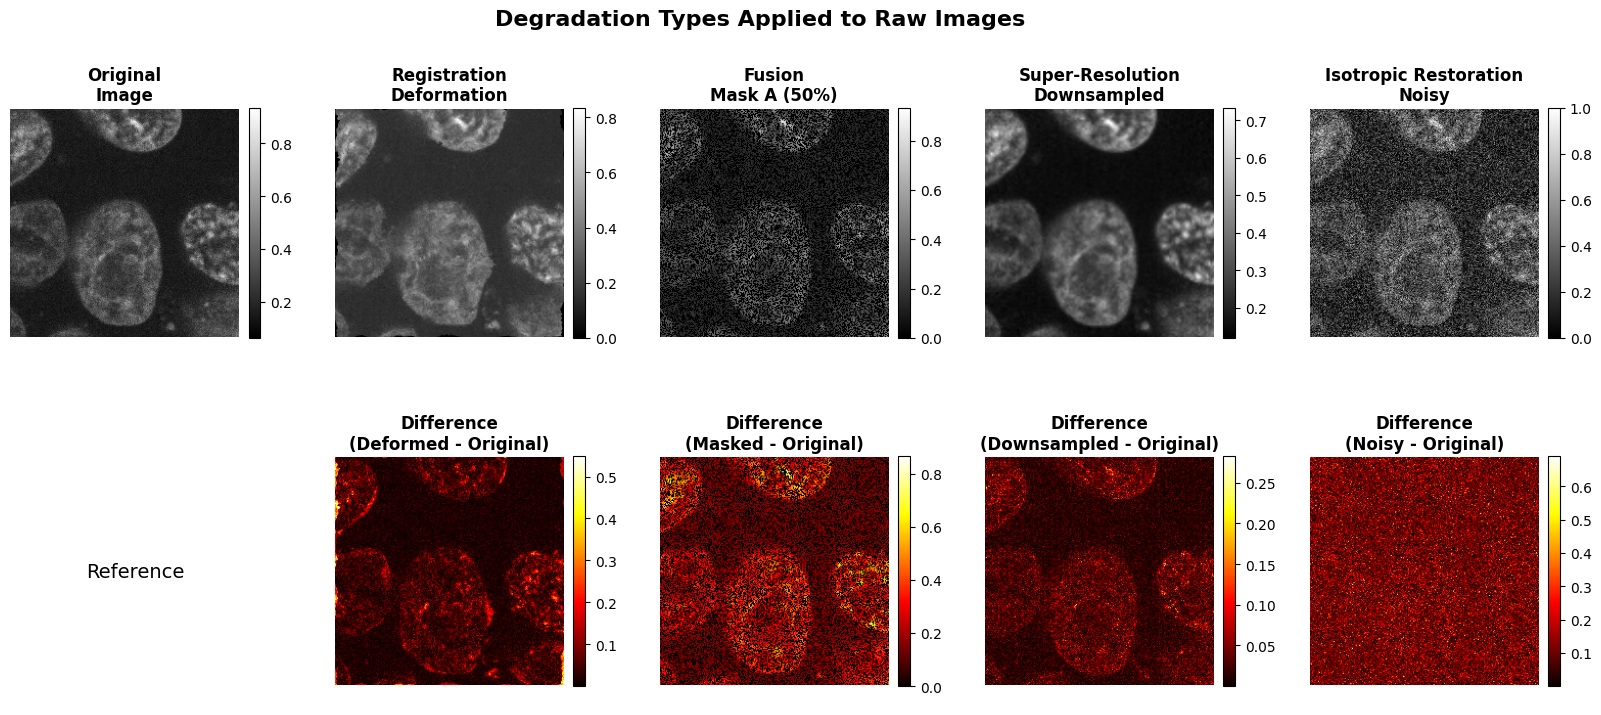


Degradation Statistics:
  Registration - Mean absolute difference: 0.036839
  Fusion - Mean absolute difference: 0.105143
  SR - Mean absolute difference: 0.020202
  IR - Mean absolute difference: 0.109797


In [13]:
# Visualize degradations side-by-side
fig = plt.figure(figsize=(20, 8))
gs = GridSpec(2, 5, figure=fig, hspace=0.3, wspace=0.3)

slice_idx = raw_image.shape[2] // 2  # Middle depth slice

# Row 1: Original and 4 degradations
ax1 = fig.add_subplot(gs[0, 0])
visualize_slice(get_middle_slice(raw_image[0]), "Original\nImage", ax=ax1)

ax2 = fig.add_subplot(gs[0, 1])
visualize_slice(get_middle_slice(reg_degraded[0]), "Registration\nDeformation", ax=ax2)

ax3 = fig.add_subplot(gs[0, 2])
visualize_slice(get_middle_slice(fus_mask_A[0]), "Fusion\nMask A (50%)", ax=ax3)

ax4 = fig.add_subplot(gs[0, 3])
visualize_slice(get_middle_slice(sr_degraded[0]), "Super-Resolution\nDownsampled", ax=ax4)

ax5 = fig.add_subplot(gs[0, 4])
visualize_slice(get_middle_slice(ir_degraded[0]), "Isotropic Restoration\nNoisy", ax=ax5)

# Row 2: Difference maps (degraded - original)
ax6 = fig.add_subplot(gs[1, 0])
ax6.text(0.5, 0.5, 'Reference', ha='center', va='center', fontsize=14)
ax6.axis('off')

ax7 = fig.add_subplot(gs[1, 1])
diff_reg = torch.abs(reg_degraded[0] - raw_image[0])
visualize_slice(get_middle_slice(diff_reg), "Difference\n(Deformed - Original)", ax=ax7, cmap='hot')

ax8 = fig.add_subplot(gs[1, 2])
diff_fus = torch.abs(fus_mask_A[0] - raw_image[0])
visualize_slice(get_middle_slice(diff_fus), "Difference\n(Masked - Original)", ax=ax8, cmap='hot')

ax9 = fig.add_subplot(gs[1, 3])
diff_sr = torch.abs(sr_degraded[0] - raw_image[0])
visualize_slice(get_middle_slice(diff_sr), "Difference\n(Downsampled - Original)", ax=ax9, cmap='hot')

ax10 = fig.add_subplot(gs[1, 4])
diff_ir = torch.abs(ir_degraded[0] - raw_image[0])
visualize_slice(get_middle_slice(diff_ir), "Difference\n(Noisy - Original)", ax=ax10, cmap='hot')

fig.suptitle('Degradation Types Applied to Raw Images', fontsize=16, fontweight='bold', y=0.98)
plt.show()

print("\nDegradation Statistics:")
print(f"  Registration - Mean absolute difference: {diff_reg.mean():.6f}")
print(f"  Fusion - Mean absolute difference: {diff_fus.mean():.6f}")
print(f"  SR - Mean absolute difference: {diff_sr.mean():.6f}")
print(f"  IR - Mean absolute difference: {diff_ir.mean():.6f}")

## 6. Visualize Encoder Inputs (What Encoder Sees)

In [14]:
# Prepare encoder inputs for each task
with torch.no_grad():
    # Registration: [deformed, original]
    reg_input = torch.cat([reg_degraded, raw_image], dim=1)  # (1, 2, D, H, W)
    
    # Fusion: [mask_A, mask_B]
    fus_input = torch.cat([fus_mask_A, fus_mask_B], dim=1)  # (1, 2, D, H, W)
    
    # Super-Resolution: [downsampled, downsampled]
    sr_input = torch.cat([sr_degraded, sr_degraded], dim=1)  # (1, 2, D, H, W)
    
    # Isotropic Restoration: [noisy, noisy]
    ir_input = torch.cat([ir_degraded, ir_degraded], dim=1)  # (1, 2, D, H, W)

print("Encoder Input Shapes:")
print(f"  Registration: {reg_input.shape}")
print(f"  Fusion: {fus_input.shape}")
print(f"  Super-Resolution: {sr_input.shape}")
print(f"  Isotropic Restoration: {ir_input.shape}")

Encoder Input Shapes:
  Registration: torch.Size([1, 2, 32, 224, 224])
  Fusion: torch.Size([1, 2, 32, 224, 224])
  Super-Resolution: torch.Size([1, 2, 32, 224, 224])
  Isotropic Restoration: torch.Size([1, 2, 32, 224, 224])


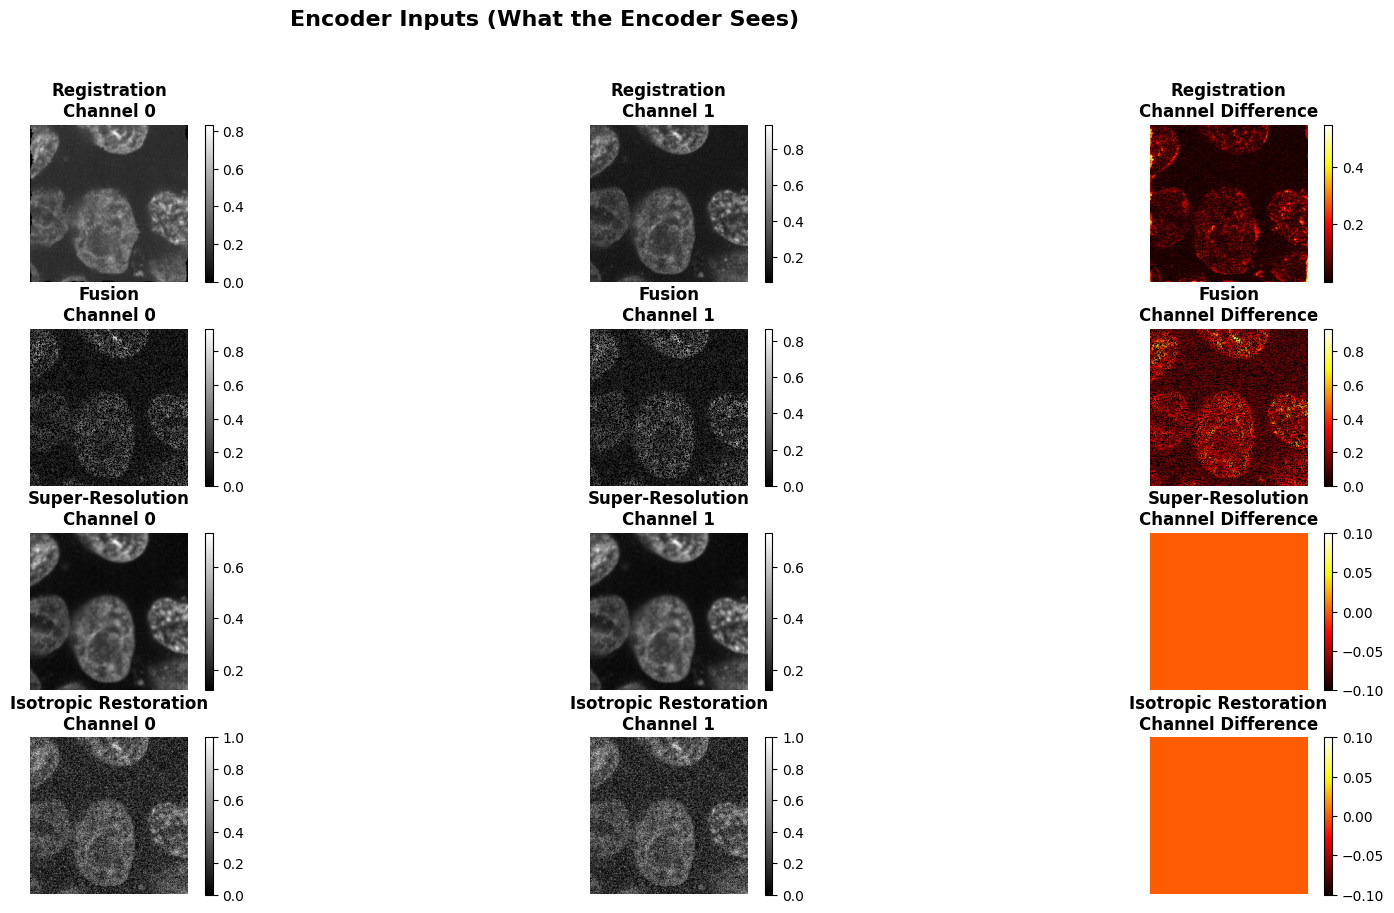

In [15]:
# Visualize encoder inputs (both channels)
fig = plt.figure(figsize=(20, 10))
gs = GridSpec(4, 3, figure=fig, hspace=0.3, wspace=0.3)

tasks = [
    (reg_input, 'Registration'),
    (fus_input, 'Fusion'),
    (sr_input, 'Super-Resolution'),
    (ir_input, 'Isotropic Restoration')
]

for i, (task_input, task_name) in enumerate(tasks):
    # Channel 0
    ax1 = fig.add_subplot(gs[i, 0])
    visualize_slice(get_middle_slice(task_input[0, 0:1]), 
                   f"{task_name}\nChannel 0", ax=ax1)
    
    # Channel 1
    ax2 = fig.add_subplot(gs[i, 1])
    visualize_slice(get_middle_slice(task_input[0, 1:2]), 
                   f"{task_name}\nChannel 1", ax=ax2)
    
    # Difference between channels
    ax3 = fig.add_subplot(gs[i, 2])
    diff = torch.abs(task_input[0, 0:1] - task_input[0, 1:2])
    visualize_slice(get_middle_slice(diff), 
                   f"{task_name}\nChannel Difference", ax=ax3, cmap='hot')

fig.suptitle('Encoder Inputs (What the Encoder Sees)', fontsize=16, fontweight='bold', y=0.995)
plt.show()

## 7. Visualize Encoder Feature Maps

In [16]:
# Extract encoder features at different levels
# We'll use registration task as example

with torch.no_grad():
    encoder_features = model.encoder(reg_input)

print("\nEncoder Feature Shapes:")
for i, feat in enumerate(encoder_features):
    print(f"  Level {i}: {feat.shape}")


Encoder Feature Shapes:
  Level 0: torch.Size([1, 2, 32, 224, 224])
  Level 1: torch.Size([1, 128, 8, 56, 56])
  Level 2: torch.Size([1, 256, 4, 28, 28])
  Level 3: torch.Size([1, 512, 2, 14, 14])
  Level 4: torch.Size([1, 1024, 1, 7, 7])


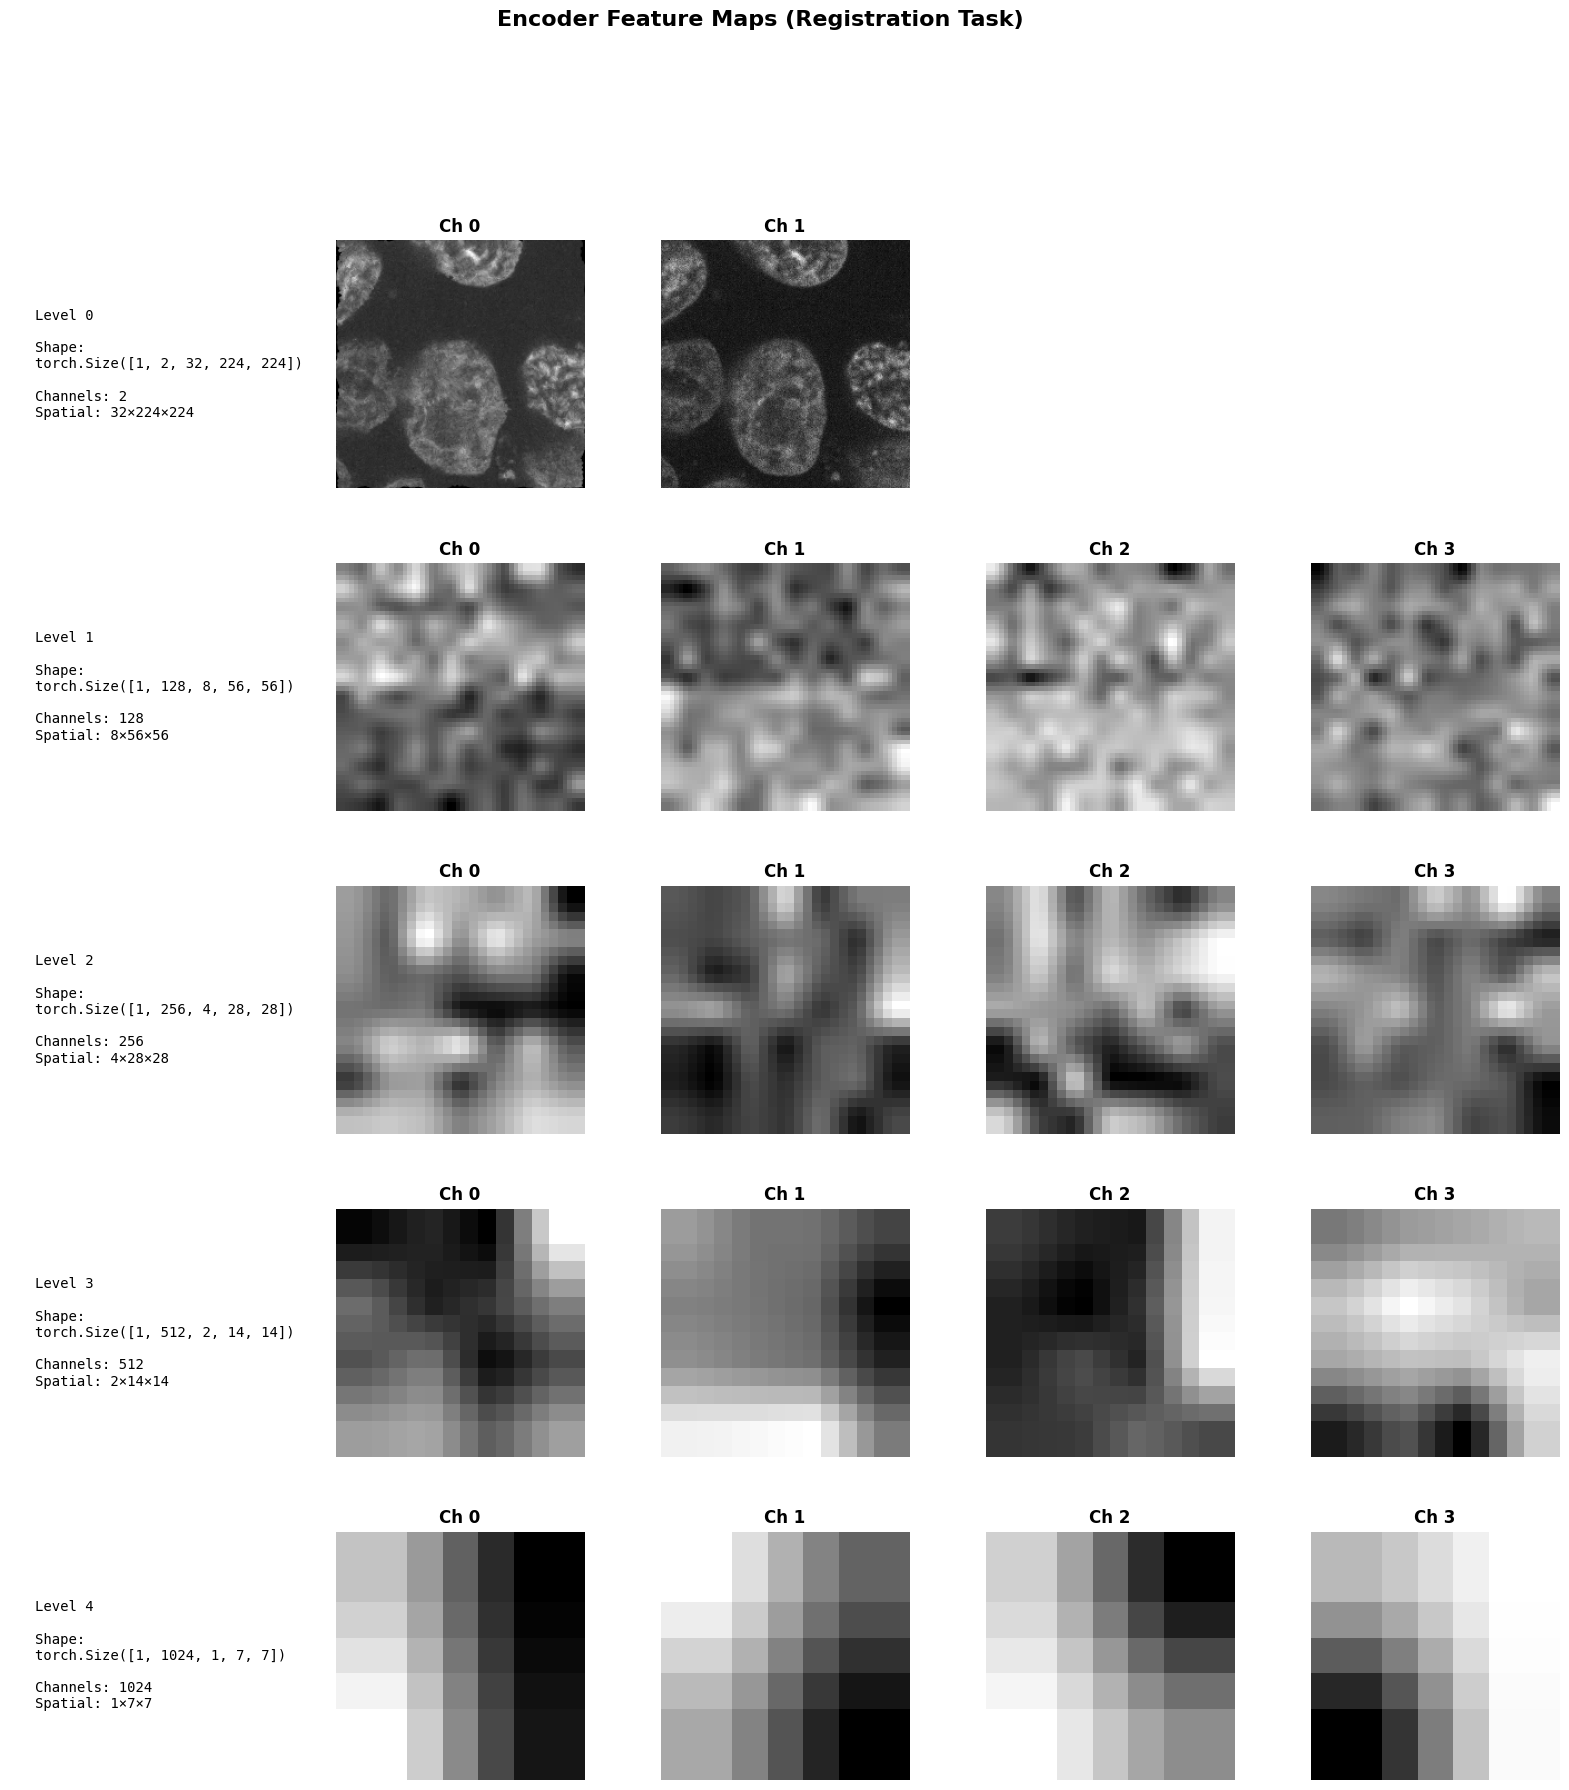

In [17]:
# Visualize first few channels of each encoder level
num_levels = len(encoder_features)
num_channels_to_show = 4

fig = plt.figure(figsize=(20, 4 * num_levels))
gs = GridSpec(num_levels, num_channels_to_show + 1, figure=fig, hspace=0.3, wspace=0.3)

for level_idx, features in enumerate(encoder_features):
    b, c, d, h, w = features.shape
    
    # Show level info
    ax_info = fig.add_subplot(gs[level_idx, 0])
    info_text = f"Level {level_idx}\n\nShape:\n{features.shape}\n\nChannels: {c}\nSpatial: {d}×{h}×{w}"
    ax_info.text(0.1, 0.5, info_text, fontsize=10, va='center', family='monospace')
    ax_info.axis('off')
    
    # Show first few channels
    for ch_idx in range(min(num_channels_to_show, c)):
        ax = fig.add_subplot(gs[level_idx, ch_idx + 1])
        channel_slice = get_middle_slice(features[0, ch_idx:ch_idx+1])
        channel_slice_norm = normalize_for_display(channel_slice)
        visualize_slice(channel_slice_norm, 
                       f"Ch {ch_idx}", ax=ax, colorbar=False)

fig.suptitle('Encoder Feature Maps (Registration Task)', fontsize=16, fontweight='bold', y=0.995)
plt.show()

## 8. Run Full Forward Pass and Visualize Outputs

In [18]:
# Run full forward pass through model
with torch.no_grad():
    logits, aux_loss = model(raw_image)

print("\nModel Outputs:")
print("\nLogits keys:", list(logits.keys()))
print("\nAux loss:", {k: {kk: f"{vv:.6f}" for kk, vv in v.items()} for k, v in aux_loss.items()})


Model Outputs:

Logits keys: ['raw', 'reg', 'fus', 'SR', 'IR']

Aux loss: {'mse': {'reg': '0.003868', 'fus': '0.050348', 'SR': '0.050246', 'IR': '0.050272'}, 'ncc': {'reg': '0.505197'}, 'grad': {'reg': '0.000000'}}


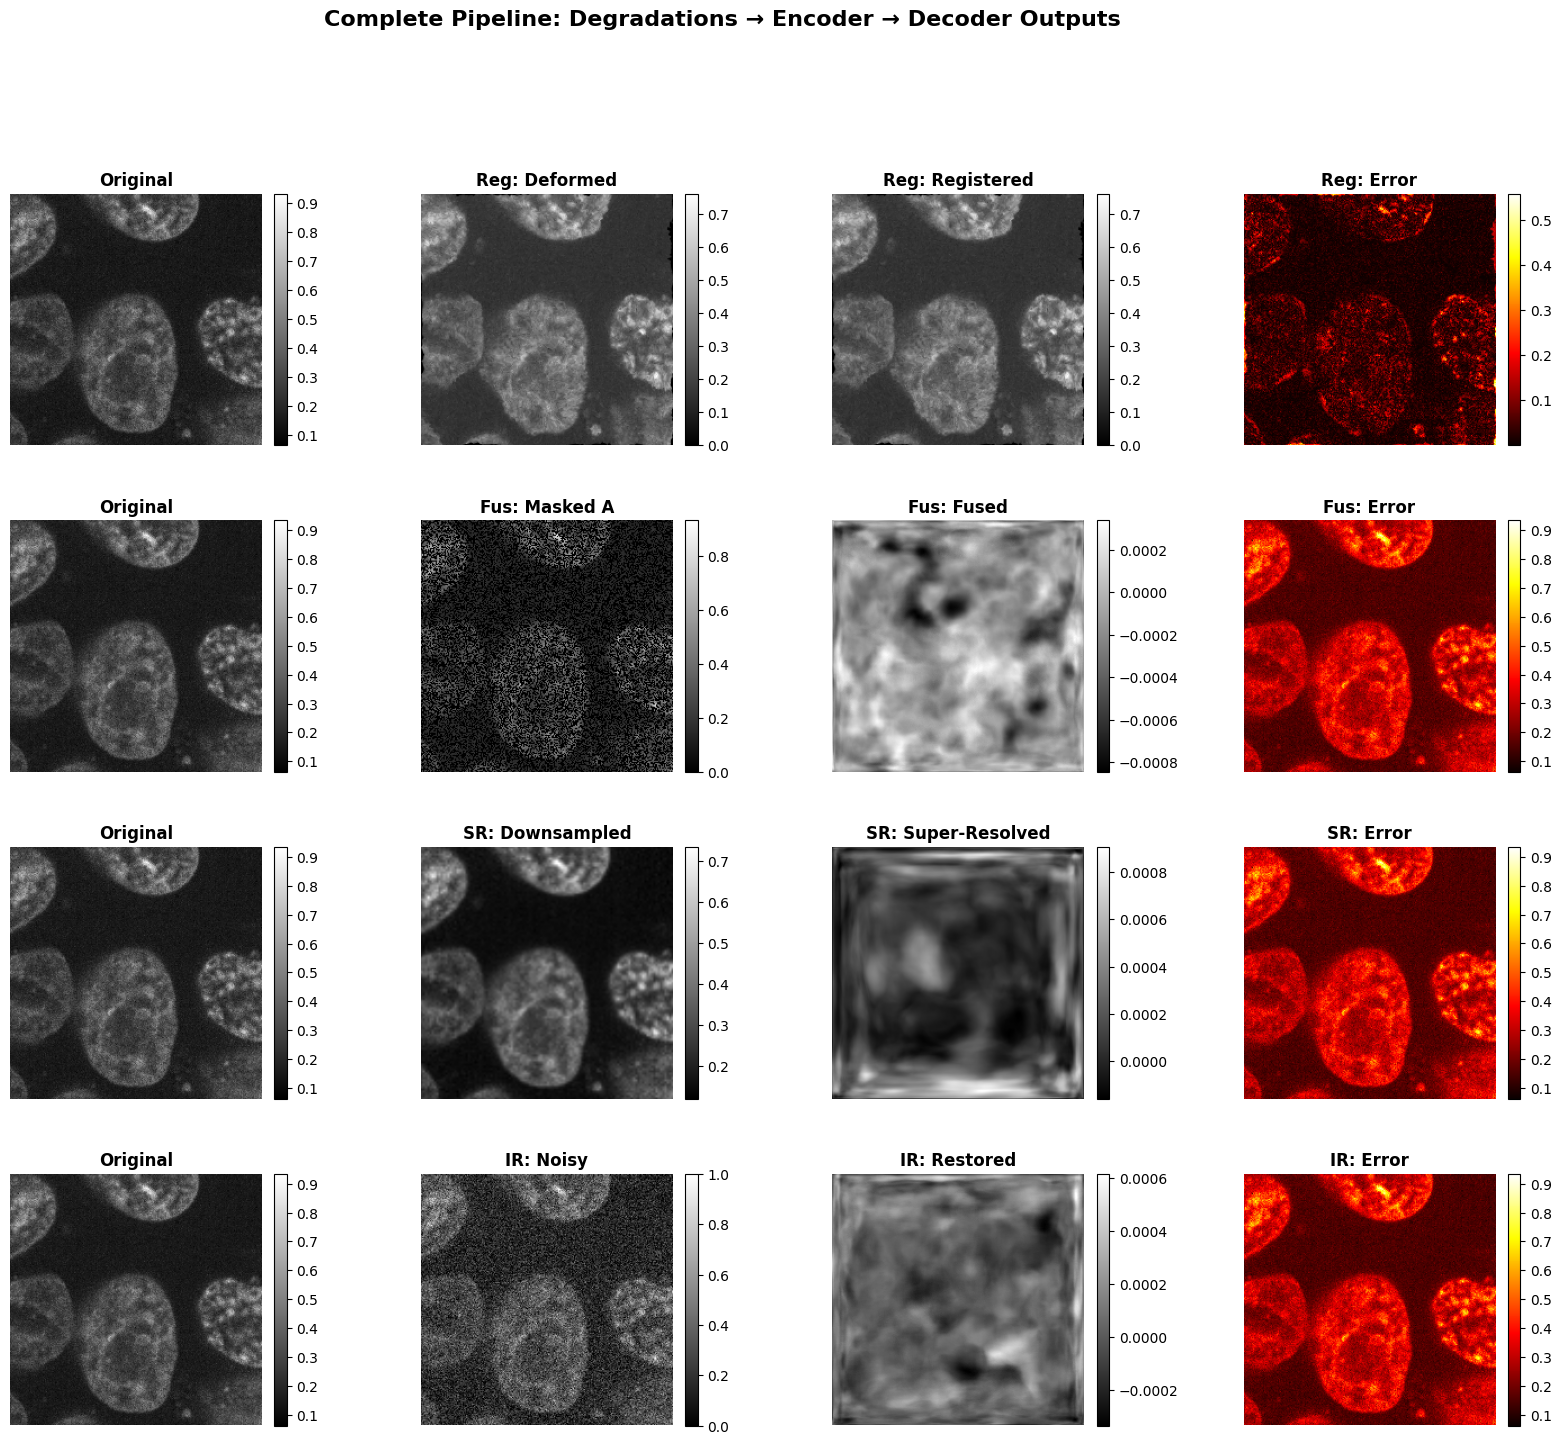

In [20]:
# Visualize all task outputs
fig = plt.figure(figsize=(20, 16))
gs = GridSpec(4, 4, figure=fig, hspace=0.3, wspace=0.3)

# Registration
if 'reg' in logits:
    ax1 = fig.add_subplot(gs[0, 0])
    visualize_slice(get_middle_slice(torch.from_numpy(logits['raw'])[0]), 
                   "Original", ax=ax1)
    
    ax2 = fig.add_subplot(gs[0, 1])
    visualize_slice(get_middle_slice(torch.from_numpy(logits['reg']['deformed'])[0]), 
                   "Reg: Deformed", ax=ax2)
    
    ax3 = fig.add_subplot(gs[0, 2])
    visualize_slice(get_middle_slice(torch.from_numpy(logits['reg']['registered'])[0]), 
                   "Reg: Registered", ax=ax3)
    
    ax4 = fig.add_subplot(gs[0, 3])
    diff = torch.abs(torch.from_numpy(logits['reg']['registered']) - torch.from_numpy(logits['raw']))
    visualize_slice(get_middle_slice(diff[0]), 
                   "Reg: Error", ax=ax4, cmap='hot')

# Fusion
if 'fus' in logits:
    ax5 = fig.add_subplot(gs[1, 0])
    visualize_slice(get_middle_slice(torch.from_numpy(logits['raw'])[0]), 
                   "Original", ax=ax5)
    
    ax6 = fig.add_subplot(gs[1, 1])
    visualize_slice(get_middle_slice(torch.from_numpy(logits['fus']['masked_A'])[0]), 
                   "Fus: Masked A", ax=ax6)
    
    ax7 = fig.add_subplot(gs[1, 2])
    visualize_slice(get_middle_slice(torch.from_numpy(logits['fus']['fused'])[0]), 
                   "Fus: Fused", ax=ax7)
    
    ax8 = fig.add_subplot(gs[1, 3])
    diff = torch.abs(torch.from_numpy(logits['fus']['fused']) - torch.from_numpy(logits['raw']))
    visualize_slice(get_middle_slice(diff[0]), 
                   "Fus: Error", ax=ax8, cmap='hot')

# Super-Resolution
if 'SR' in logits:
    ax9 = fig.add_subplot(gs[2, 0])
    visualize_slice(get_middle_slice(torch.from_numpy(logits['raw'])[0]), 
                   "Original", ax=ax9)
    
    ax10 = fig.add_subplot(gs[2, 1])
    visualize_slice(get_middle_slice(torch.from_numpy(logits['SR']['downsampled'])[0]), 
                   "SR: Downsampled", ax=ax10)
    
    ax11 = fig.add_subplot(gs[2, 2])
    visualize_slice(get_middle_slice(torch.from_numpy(logits['SR']['super_resolution'])[0]), 
                   "SR: Super-Resolved", ax=ax11)
    
    ax12 = fig.add_subplot(gs[2, 3])
    diff = torch.abs(torch.from_numpy(logits['SR']['super_resolution']) - torch.from_numpy(logits['raw']))
    visualize_slice(get_middle_slice(diff[0]), 
                   "SR: Error", ax=ax12, cmap='hot')

# Isotropic Restoration
if 'IR' in logits:
    ax13 = fig.add_subplot(gs[3, 0])
    visualize_slice(get_middle_slice(torch.from_numpy(logits['raw'])[0]), 
                   "Original", ax=ax13)
    
    ax14 = fig.add_subplot(gs[3, 1])
    visualize_slice(get_middle_slice(torch.from_numpy(logits['IR']['noisy'])[0]), 
                   "IR: Noisy", ax=ax14)
    
    ax15 = fig.add_subplot(gs[3, 2])
    visualize_slice(get_middle_slice(torch.from_numpy(logits['IR']['restored'])[0]), 
                   "IR: Restored", ax=ax15)
    
    ax16 = fig.add_subplot(gs[3, 3])
    diff = torch.abs(torch.from_numpy(logits['IR']['restored']) - torch.from_numpy(logits['raw']))
    visualize_slice(get_middle_slice(diff[0]), 
                   "IR: Error", ax=ax16, cmap='hot')

fig.suptitle('Complete Pipeline: Degradations → Encoder → Decoder Outputs', 
             fontsize=16, fontweight='bold', y=0.995)
plt.show()

## 9. Summary Statistics

In [22]:
print("="*70)
print("DEGRADATION & RESTORATION SUMMARY")
print("="*70)

print("\n📊 Loss Values:")
for loss_type, tasks in aux_loss.items():
    print(f"\n  {loss_type.upper()}:")
    for task, value in tasks.items():
        print(f"    {task}: {value:.6f}")

print("\n📐 Image Statistics:")
print(f"  Raw image range: [{raw_image.min():.4f}, {raw_image.max():.4f}]")
print(f"  Raw image mean: {raw_image.mean():.4f}")
print(f"  Raw image std: {raw_image.std():.4f}")

if 'reg' in logits:
    reg_restored = torch.from_numpy(logits['reg']['registered'])
    print(f"\n  Registration restored range: [{reg_restored.min():.4f}, {reg_restored.max():.4f}]")
    print(f"  Registration MAE: {torch.abs(reg_restored - torch.from_numpy(logits['raw'])).mean():.6f}")

if 'fus' in logits:
    fus_restored = torch.from_numpy(logits['fus']['fused'])
    print(f"\n  Fusion restored range: [{fus_restored.min():.4f}, {fus_restored.max():.4f}]")
    print(f"  Fusion MAE: {torch.abs(fus_restored - torch.from_numpy(logits['raw'])).mean():.6f}")

if 'SR' in logits:
    sr_restored = torch.from_numpy(logits['SR']['super_resolution'])
    print(f"\n  SR restored range: [{sr_restored.min():.4f}, {sr_restored.max():.4f}]")
    print(f"  SR MAE: {torch.abs(sr_restored - torch.from_numpy(logits['raw'])).mean():.6f}")

if 'IR' in logits:
    ir_restored = torch.from_numpy(logits['IR']['restored'])
    print(f"\n  IR restored range: [{ir_restored.min():.4f}, {ir_restored.max():.4f}]")
    print(f"  IR MAE: {torch.abs(ir_restored - torch.from_numpy(logits['raw'])).mean():.6f}")

print("\n" + "="*70)
print("✓ Visualization complete!")
print("="*70)

DEGRADATION & RESTORATION SUMMARY

📊 Loss Values:

  MSE:
    reg: 0.003868
    fus: 0.050348
    SR: 0.050246
    IR: 0.050272

  NCC:
    reg: 0.505197

  GRAD:
    reg: 0.000000

📐 Image Statistics:
  Raw image range: [0.0000, 0.9329]
  Raw image mean: 0.2101
  Raw image std: 0.0783

  Registration restored range: [0.0000, 0.8496]
  Registration MAE: 0.038586

  Fusion restored range: [-0.0012, 0.0005]
  Fusion MAE: 0.210282

  SR restored range: [-0.0003, 0.0010]
  SR MAE: 0.210031

  IR restored range: [-0.0004, 0.0007]
  IR MAE: 0.210095

✓ Visualization complete!
